# Phase 2a: Anomaly Detection on MetroPT-3

**Goal:** detect abnormal compressor behaviour **without using failure labels for training**.
We train only on normal data, then check whether the anomaly score rises before and during the 4 known failures.

**Pipeline**
1. Aggregate raw sensor data into 10-minute windows (features)
2. Time-based split (train = early normal data only)
3. Baseline: Isolation Forest
4. Deep model: LSTM Autoencoder (reconstruction error = anomaly score)
5. Compare both, then save models to `ml/models/`

**Needs:** `data/processed/metropt3_labeled.parquet` and `failures.json` from notebook 01.
Install once: `pip install scikit-learn torch joblib`

## 0. Imports and config

In [3]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROC_DIR = Path("../data/processed")
MODEL_DIR = Path("../ml/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
ANALOG = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
DIGITAL = ["COMP", "DV_eletric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]

# ---- tunable settings ----
WINDOW = "10min"                       # aggregation window
SEQ_LEN = 12                           # LSTM looks at 12 windows = 2 hours
MARGIN = pd.Timedelta("24h")           # how far before a failure an alert still counts as early
TRAIN_END = pd.Timestamp("2020-04-17") # train only on data before this date (before failure 1)
VAL_END = pd.Timestamp("2020-06-01")   # val = failures 1-2, test = failures 3-4
THRESH_QUANTILE = 0.995                # threshold = this quantile of NORMAL scores
MIN_CONSEC = 3                         # alert only if flagged for 3 windows in a row (30 min)
EPOCHS = 40

## 1. Load data and failure windows

In [4]:
df = pd.read_parquet(PROC_DIR / "metropt3_labeled.parquet")
with open(PROC_DIR / "failures.json") as f:
    failures = [(pd.Timestamp(x["start"]), pd.Timestamp(x["end"])) for x in json.load(f)]

print("Raw rows:", df.shape, "| range:", df.index.min(), "->", df.index.max())
for i, (s, e) in enumerate(failures, 1):
    print(f"Failure {i}: {s} -> {e}")

Raw rows: (1516948, 17) | range: 2020-02-01 00:00:00 -> 2020-09-01 03:59:50
Failure 1: 2020-04-18 00:00:00 -> 2020-04-18 23:59:00
Failure 2: 2020-05-29 23:30:00 -> 2020-05-30 06:00:00
Failure 3: 2020-06-05 10:00:00 -> 2020-06-07 14:30:00
Failure 4: 2020-07-15 14:30:00 -> 2020-07-15 19:00:00


## 2. Build window features

Raw data is 1.5M noisy rows. Each 10-minute window becomes one row:
- analog sensors: mean, std, min, max
- digital sensors: mean (= fraction of time ON)

Windows with too few readings (machine off / data gaps) are dropped.

In [5]:
agg = {c: ["mean", "std", "min", "max"] for c in ANALOG}
agg.update({c: ["mean"] for c in DIGITAL})

feat = df.resample(WINDOW).agg(agg)
feat.columns = [f"{c}_{s}" for c, s in feat.columns]

feat["n_rows"] = df[ANALOG[0]].resample(WINDOW).count()
feat["is_failure"] = df["is_failure"].resample(WINDOW).max()
feat["fail_within_h"] = df["fail_within_h"].resample(WINDOW).max()

# drop windows where the machine was off or data is missing
typical = feat.loc[feat["n_rows"] > 0, "n_rows"].median()
feat = feat[feat["n_rows"] >= 0.5 * typical].copy()
feat = feat.fillna(0)
feat[["is_failure", "fail_within_h"]] = feat[["is_failure", "fail_within_h"]].astype(int)

FEATURES = [c for c in feat.columns if c not in ["n_rows", "is_failure", "fail_within_h"]]
print("Windows kept:", len(feat), "| features:", len(FEATURES))
feat[FEATURES].head()

Windows kept: 25256 | features: 36


,TP2_mean,TP2_std,TP2_min,TP2_max,TP3_mean,TP3_std,TP3_min,TP3_max,H1_mean,H1_std,...,Motor_current_min,Motor_current_max,COMP_mean,DV_eletric_mean,Towers_mean,MPG_mean,LPS_mean,Pressure_switch_mean,Oil_level_mean,Caudal_impulses_mean
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.013016,0.001008,-0.014,-0.012,9.053705,0.177553,8.760,9.358,9.038230,0.176852,...,0.0375,0.0425,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0
2020-02-01 00:10:00,-0.013836,0.000757,-0.016,-0.012,8.480361,0.156157,8.222,8.750,8.466590,0.155983,...,0.0350,0.0400,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0
2020-02-01 00:20:00,1.570033,3.580866,-0.026,10.314,9.169833,0.793773,8.068,10.098,7.626233,3.529391,...,0.0400,6.2825,0.816667,0.183333,0.916667,0.816667,0.0,1.0,1.0,1.0
2020-02-01 00:30:00,-0.012820,0.001118,-0.014,-0.010,9.300000,0.182287,8.994,9.608,9.284262,0.182311,...,0.0375,3.9100,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0
2020-02-01 00:40:00,-0.013833,0.000763,-0.016,-0.012,8.703833,0.162246,8.436,8.984,8.689200,0.161837,...,0.0375,0.0425,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0


## 3. Time-based split

- **Train:** normal windows before `TRAIN_END` (no failures, no pre-failure period)
- **Val:** `TRAIN_END` to `VAL_END` (contains failures 1-2)
- **Test:** after `VAL_END` (contains failures 3-4)

The threshold is **not** tuned on val or test; it comes from normal training data only.

In [6]:
idx = feat.index
train_mask = (idx < TRAIN_END) & (feat["is_failure"] == 0) & (feat["fail_within_h"] == 0)
val_mask = (idx >= TRAIN_END) & (idx < VAL_END)
test_mask = idx >= VAL_END

summary = pd.DataFrame({
    "windows": [train_mask.sum(), val_mask.sum(), test_mask.sum()],
    "failure_windows": [feat.loc[train_mask, "is_failure"].sum(),
                        feat.loc[val_mask, "is_failure"].sum(),
                        feat.loc[test_mask, "is_failure"].sum()],
}, index=["train", "val", "test"])
print(summary)
assert summary.loc["train", "failure_windows"] == 0
assert summary.loc["train", "windows"] > 1000, "Too little training data - check TRAIN_END"

       windows  failure_windows
train     9198                0
val       5049              183
test     11009              314


In [7]:
# Fit the scaler on TRAIN ONLY (no leakage), then scale everything
scaler = StandardScaler().fit(feat.loc[train_mask, FEATURES])
X = pd.DataFrame(scaler.transform(feat[FEATURES]), index=feat.index, columns=FEATURES)
y_all = feat["is_failure"]

## 4. Helper functions (metrics, alerts, plots)

In [8]:
def in_failure_zone(index, failures, margin=MARGIN):
    zone = np.zeros(len(index), dtype=bool)
    for s, e in failures:
        zone |= (index >= s - margin) & (index <= e)
    return zone


def window_metrics(score, y, thresh):
    # Window-level metrics: is this 10-min window inside a failure?
    out = {"prevalence": y.mean()}
    if 0 < y.sum() < len(y):
        out["roc_auc"] = roc_auc_score(y, score)
        out["pr_auc"] = average_precision_score(y, score)   # compare with prevalence!
    pred = (score > thresh).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
    out.update(precision=p, recall=r, f1=f)
    return out


def alert_report(score, thresh, failures, min_consec=MIN_CONSEC, margin=MARGIN):
    # Event-level view: how early did we alert, and how many false alarms?
    flagged = (score > thresh).astype(int)
    sustained = flagged.rolling(min_consec).min().fillna(0).astype(bool)

    rows = []
    for i, (s, e) in enumerate(failures, 1):
        seg = sustained[(sustained.index >= s - margin) & (sustained.index <= e)]
        hits = seg[seg]
        if len(hits):
            t = hits.index[0]
            rows.append({"failure": i, "first_alert": t, "lead_hours": round((s - t).total_seconds() / 3600, 1)})
        else:
            rows.append({"failure": i, "first_alert": pd.NaT, "lead_hours": np.nan})

    zone = in_failure_zone(score.index, failures, margin)
    outside = sustained & ~zone
    false_alarm_episodes = int((outside & ~outside.shift(fill_value=False)).sum())
    return pd.DataFrame(rows), false_alarm_episodes


def plot_scores(score, thresh, title, start=TRAIN_END):
    s = score[score.index >= start].dropna()
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(s.index, s.values, lw=0.5, label="anomaly score")
    ax.plot(s.index, s.rolling(6).mean(), lw=1.2, color="black", alpha=0.7, label="1h rolling mean")
    ax.axhline(thresh, color="orange", ls="--", label="threshold")
    for i, (fs, fe) in enumerate(failures):
        ax.axvspan(fs, fe, color="red", alpha=0.3, label="failure" if i == 0 else None)
    ax.set_title(title)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

## 5. Baseline: Isolation Forest

Trained on normal windows only. Higher score = more anomalous.

Isolation Forest threshold: 0.6745


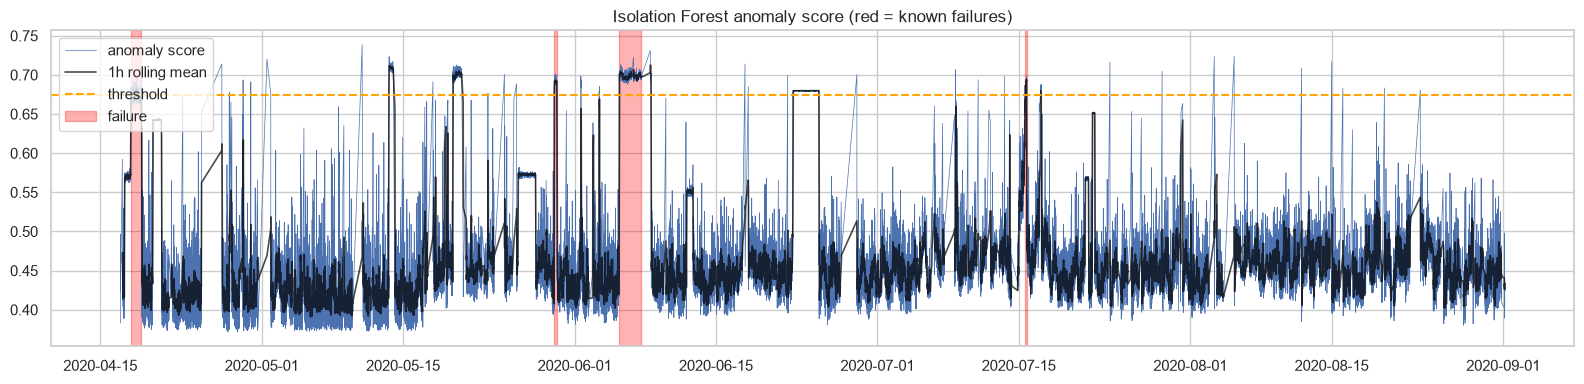

In [9]:
iso = IsolationForest(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X[train_mask])

if_score = pd.Series(-iso.score_samples(X), index=X.index)   # flip sign: higher = more anomalous
if_thresh = if_score[train_mask].quantile(THRESH_QUANTILE)
print(f"Isolation Forest threshold: {if_thresh:.4f}")

plot_scores(if_score, if_thresh, "Isolation Forest anomaly score (red = known failures)")

In [10]:
rows = {}
for name, m in [("val", val_mask), ("test", test_mask)]:
    rows[("IsolationForest", name)] = window_metrics(if_score[m], y_all[m], if_thresh)
if_metrics = pd.DataFrame(rows).T.round(3)
if_metrics

prevalence  roc_auc  pr_auc  precision  recall     f1
IsolationForest val        0.036    0.956   0.274      0.297   0.497  0.372
                test       0.029    0.996   0.827      0.424   0.965  0.589

In [11]:
eval_mask = idx >= TRAIN_END
if_alerts, if_false = alert_report(if_score[eval_mask], if_thresh, failures)
print("Isolation Forest - alert timing (lead_hours > 0 means alert BEFORE the failure started):")
print(if_alerts.to_string(index=False))
print("False-alarm episodes outside failure zones:", if_false)

Isolation Forest - alert timing (lead_hours > 0 means alert BEFORE the failure started):
 failure         first_alert  lead_hours
       1 2020-04-18 06:00:00        -6.0
       2 2020-05-29 23:40:00        -0.2
       3 2020-06-05 10:10:00        -0.2
       4 2020-07-15 17:00:00        -2.5
False-alarm episodes outside failure zones: 8


## 6. LSTM Autoencoder

The model learns to reconstruct 2-hour sequences of **normal** behaviour.
When behaviour changes (e.g., an air leak), reconstruction error rises, and that error is the anomaly score.

In [12]:
def make_sequences(Xdf, seq_len):
    # Sliding sequences of consecutive windows; skips sequences that span a time gap.
    vals = Xdf.values.astype(np.float32)
    ts = Xdf.index.values
    win = pd.Timedelta(WINDOW).to_timedelta64()
    n = len(vals) - seq_len + 1
    if n <= 0:
        return np.empty((0, seq_len, vals.shape[1]), dtype=np.float32), pd.DatetimeIndex([])
    starts = np.arange(n)
    contiguous = (ts[seq_len - 1:] - ts[:n]) == (seq_len - 1) * win
    starts = starts[contiguous]
    seqs = np.stack([vals[i:i + seq_len] for i in starts]) if len(starts) else np.empty((0, seq_len, vals.shape[1]), dtype=np.float32)
    end_times = pd.DatetimeIndex(ts[starts + seq_len - 1])
    return seqs, end_times


train_seqs, train_end_times = make_sequences(X[train_mask], SEQ_LEN)
all_seqs, all_end_times = make_sequences(X, SEQ_LEN)
print("Train sequences:", train_seqs.shape, "| All sequences:", all_seqs.shape)

Train sequences: (8529, 12, 36) | All sequences: (23222, 12, 36)


In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


class LSTMAE(nn.Module):
    def __init__(self, n_features, hidden=64, latent=16):
        super().__init__()
        self.enc = nn.LSTM(n_features, hidden, batch_first=True)
        self.to_latent = nn.Linear(hidden, latent)
        self.from_latent = nn.Linear(latent, hidden)
        self.dec = nn.LSTM(hidden, hidden, batch_first=True)
        self.out = nn.Linear(hidden, n_features)

    def forward(self, x):
        _, (h, _) = self.enc(x)
        z = self.to_latent(h[-1])                                   # compressed summary of the sequence
        d = self.from_latent(z).unsqueeze(1).repeat(1, x.size(1), 1)
        y, _ = self.dec(d)
        return self.out(y)


def recon_error(model, seqs, batch=512):
    model.eval()
    errs = []
    with torch.no_grad():
        for i in range(0, len(seqs), batch):
            xb = torch.from_numpy(seqs[i:i + batch]).to(device)
            errs.append(((model(xb) - xb) ** 2).mean(dim=(1, 2)).cpu().numpy())
    return np.concatenate(errs)

Using device: cpu


In [14]:
# Chronological hold-out: last 10% of the training sequences are used for early stopping + threshold
split = int(len(train_seqs) * 0.9)
tr, ho = train_seqs[:split], train_seqs[split:]

model = LSTMAE(n_features=len(FEATURES)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
loader = DataLoader(TensorDataset(torch.from_numpy(tr)), batch_size=128, shuffle=True)

best_val, best_state, patience, bad = np.inf, None, 6, 0
history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0
    for (xb,) in loader:
        xb = xb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), xb)
        loss.backward()
        opt.step()
        total += loss.item() * len(xb)
    train_loss = total / len(tr)
    val_loss = recon_error(model, ho).mean()
    history.append((train_loss, val_loss))
    print(f"epoch {epoch:02d}  train {train_loss:.4f}  holdout {val_loss:.4f}")
    if val_loss < best_val - 1e-4:
        best_val, bad = val_loss, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)

epoch 01  train 0.7059  holdout 0.8808
epoch 02  train 0.5566  holdout 0.8535
epoch 03  train 0.5421  holdout 0.8216
epoch 04  train 0.5348  holdout 0.8030
epoch 05  train 0.5287  holdout 0.8032
epoch 06  train 0.5231  holdout 0.7856
epoch 07  train 0.5186  holdout 0.7688
epoch 08  train 0.5144  holdout 0.7794
epoch 09  train 0.5088  holdout 0.7575
epoch 10  train 0.5074  holdout 0.7680
epoch 11  train 0.5031  holdout 0.7849
epoch 12  train 0.5005  holdout 0.7743
epoch 13  train 0.4965  holdout 0.7553
epoch 14  train 0.4963  holdout 0.7374
epoch 15  train 0.4917  holdout 0.7441
epoch 16  train 0.4878  holdout 0.7474
epoch 17  train 0.4834  holdout 0.7360
epoch 18  train 0.4647  holdout 0.6751
epoch 19  train 0.4144  holdout 0.6047
epoch 20  train 0.3669  holdout 0.5630
epoch 21  train 0.3256  holdout 0.5101
epoch 22  train 0.3049  holdout 0.5012
epoch 23  train 0.2933  holdout 0.4933
epoch 24  train 0.2818  holdout 0.4746
epoch 25  train 0.2728  holdout 0.4756
epoch 26  train 0.2671  h

<All keys matched successfully>

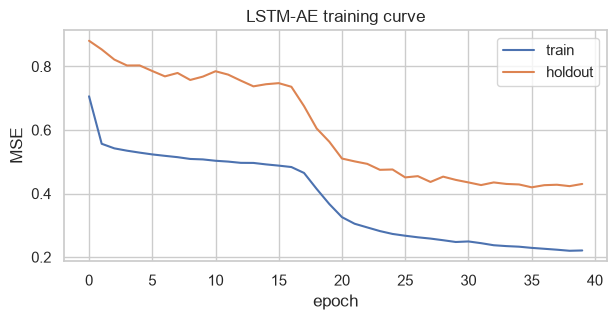

In [15]:
h = np.array(history)
plt.figure(figsize=(7, 3))
plt.plot(h[:, 0], label="train")
plt.plot(h[:, 1], label="holdout")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("LSTM-AE training curve")
plt.show()

LSTM-AE threshold: 4.0241


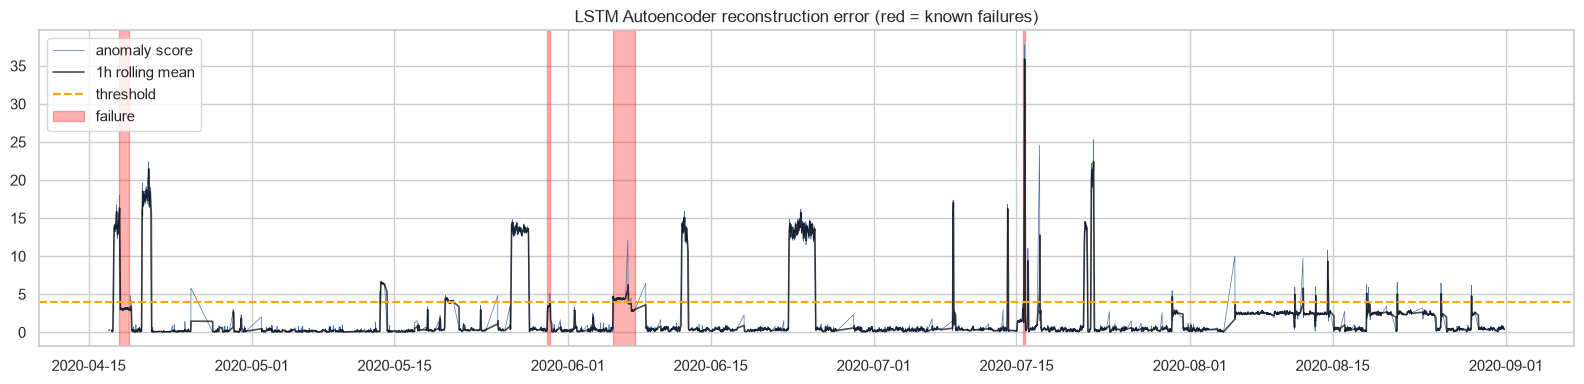

In [16]:
errs = recon_error(model, all_seqs)
lstm_score = pd.Series(errs, index=all_end_times).reindex(feat.index)   # NaN where no full sequence exists

lstm_thresh = float(np.quantile(recon_error(model, ho), THRESH_QUANTILE))
print(f"LSTM-AE threshold: {lstm_thresh:.4f}")

plot_scores(lstm_score, lstm_thresh, "LSTM Autoencoder reconstruction error (red = known failures)")

In [17]:
rows = {}
for name, m in [("val", val_mask), ("test", test_mask)]:
    s = lstm_score[m].dropna()
    rows[("LSTM-AE", name)] = window_metrics(s, y_all.loc[s.index], lstm_thresh)
lstm_metrics = pd.DataFrame(rows).T.round(3)

lstm_alerts, lstm_false = alert_report(lstm_score[eval_mask].dropna(), lstm_thresh, failures)
print("LSTM-AE - alert timing (lead_hours > 0 means alert BEFORE the failure started):")
print(lstm_alerts.to_string(index=False))
print("False-alarm episodes outside failure zones:", lstm_false)
lstm_metrics

LSTM-AE - alert timing (lead_hours > 0 means alert BEFORE the failure started):
 failure         first_alert  lead_hours
       1 2020-04-17 10:20:00        13.7
       2                 NaT         NaN
       3 2020-06-05 10:30:00        -0.5
       4 2020-07-15 17:40:00        -3.2
False-alarm episodes outside failure zones: 32


prevalence  roc_auc  pr_auc  precision  recall     f1
LSTM-AE val        0.040    0.855   0.118      0.020   0.066  0.030
        test       0.029    0.925   0.177      0.222   0.661  0.332

## 7. Compare the two models

How to read this:
- **pr_auc vs prevalence:** failures are rare, so PR-AUC should be compared with `prevalence`, not with 0.5.
- **lead_hours:** positive = alert before failure started (the useful case).
- **false-alarm episodes:** too many and nobody trusts the alerts.

In [18]:
comparison = pd.concat([if_metrics, lstm_metrics])
print(comparison.to_string())
print()
summary_rows = []
for name, alerts, fa in [("IsolationForest", if_alerts, if_false), ("LSTM-AE", lstm_alerts, lstm_false)]:
    summary_rows.append({
        "model": name,
        "failures_detected": int(alerts["first_alert"].notna().sum()),
        "of": len(alerts),
        "median_lead_hours": alerts["lead_hours"].median(),
        "false_alarm_episodes": fa,
    })
pd.DataFrame(summary_rows)

                      prevalence  roc_auc  pr_auc  precision  recall     f1
IsolationForest val        0.036    0.956   0.274      0.297   0.497  0.372
                test       0.029    0.996   0.827      0.424   0.965  0.589
LSTM-AE         val        0.040    0.855   0.118      0.020   0.066  0.030
                test       0.029    0.925   0.177      0.222   0.661  0.332



,model,failures_detected,of,median_lead_hours,false_alarm_episodes
0,IsolationForest,4,4,-1.35,8
1,LSTM-AE,3,4,-0.50,32


## 8. Which sensors drive the anomaly? (needed later for root-cause alerts)

For one failure, compare the scaled feature values just before it with normal values.
Features with the biggest deviation are the "contributing sensors" the Slack alert will report.

In [19]:
def top_contributors(failure_idx=0, hours_before=6, k=8):
    s, e = failures[failure_idx]
    seg = X.loc[s - pd.Timedelta(hours=hours_before): s]
    if seg.empty:
        return pd.Series(dtype=float)
    return seg.mean().abs().sort_values(ascending=False).head(k).round(2)

for i in range(len(failures)):
    print(f"Failure {i + 1} - top deviating features in the 6h before it started (z-scores):")
    print(top_contributors(i).to_string())
    print()

Failure 1 - top deviating features in the 6h before it started (z-scores):
Pressure_switch_mean    20.90
Oil_level_mean           5.01
Reservoirs_max           2.54
TP3_max                  2.54
Oil_temperature_max      1.97
Reservoirs_mean          1.85
TP3_mean                 1.85
Oil_temperature_mean     1.72

Failure 2 - top deviating features in the 6h before it started (z-scores):
Oil_temperature_max     0.90
Oil_temperature_mean    0.89
Oil_temperature_min     0.82
DV_pressure_mean        0.60
DV_pressure_std         0.52
Caudal_impulses_mean    0.41
DV_pressure_min         0.38
Oil_temperature_std     0.33

Failure 3 - top deviating features in the 6h before it started (z-scores):
Oil_temperature_mean    0.88
Oil_temperature_max     0.87
Oil_temperature_min     0.76
DV_pressure_mean        0.45
H1_min                  0.41
Caudal_impulses_mean    0.41
Motor_current_max       0.40
TP2_max                 0.39

Failure 4 - top deviating features in the 6h before it started (z-sc

## 9. Save models for later phases (API, streaming)

In [20]:
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
joblib.dump(iso, MODEL_DIR / "isolation_forest.joblib")
torch.save({
    "state_dict": best_state,
    "n_features": len(FEATURES),
    "hidden": 64,
    "latent": 16,
    "seq_len": SEQ_LEN,
}, MODEL_DIR / "lstm_autoencoder.pt")

config = {
    "window": WINDOW,
    "seq_len": SEQ_LEN,
    "features": FEATURES,
    "analog": ANALOG,
    "digital": DIGITAL,
    "isolation_forest_threshold": float(if_thresh),
    "lstm_threshold": float(lstm_thresh),
    "threshold_quantile": THRESH_QUANTILE,
    "min_consecutive_windows": MIN_CONSEC,
}
with open(MODEL_DIR / "anomaly_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved to", MODEL_DIR.resolve())
print(sorted(p.name for p in MODEL_DIR.iterdir()))

Saved to D:\TY\MLCP\ml\models
['anomaly_config.json', 'isolation_forest.joblib', 'lstm_autoencoder.pt', 'scaler.joblib']


## 10. Notes (fill these in)

- Did the Isolation Forest score rise before/during failures? Which ones? ...
- Did the LSTM-AE do better? By how many hours of lead time? ...
- How many false alarms? Do they cluster in a particular month (sensor drift)? ...
- Which sensors contributed most for each failure? ...
- Ideas to improve: different window size, other thresholds, more features (slopes), retraining on rolling normal data ...